In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews_all, Sort
import pandas as pd

In [ ]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
# Import library NLTK untuk preprocessing teks
import nltk

In [ ]:
# Download resource NLTK yang dibutuhkan:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Import fungsi untuk tokenisasi kata dan filtering stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [ ]:
import numpy as np
import re               # Untuk regular expression
import unicodedata      # Untuk normalisasi karakter unicode
import string           # Untuk manipulasi karakter dan tanda baca
import csv              # Untuk membaca file CSV
import requests         # Untuk mengirim permintaan HTTP
from io import StringIO # Untuk mengubah string menjadi file-like object
from sklearn.feature_extraction.text import TfidfVectorizer # Mengubah teks menjadi numerik berbasis TF-IDF

In [ ]:
# Import library untuk membuat visualisasi
from wordcloud import WordCloud  # Visualisasi berbentuk awan kata (word cloud) dari teks
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mengambil 40.000 ulasan relevan dari aplikasi Inshot dari pengguna Indonesia
hasil = reviews_all(
    'com.camerasideas.instashot',   # ID aplikasi Adobe Express
    lang='id',                # Bahasa Indonesia
    country='id',             # Negara Indonesia
    sort=Sort.MOST_RELEVANT,  # Ulasan paling relevan
    count= 40000              # Jumlah ulasan yang diambil
)


In [ ]:
# Konversi ke DataFrame
inshot_df = pd.DataFrame(hasil)

In [ ]:
inshot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              45000 non-null  object        
 1   userName              45000 non-null  object        
 2   userImage             45000 non-null  object        
 3   content               45000 non-null  object        
 4   score                 45000 non-null  int64         
 5   thumbsUpCount         45000 non-null  int64         
 6   reviewCreatedVersion  23423 non-null  object        
 7   at                    45000 non-null  datetime64[ns]
 8   replyContent          2062 non-null   object        
 9   repliedAt             2062 non-null   datetime64[ns]
 10  appVersion            23423 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 3.8+ MB


 **KESIMPULAN DATASET**

 - Melihat 40.000 ulasan aplikasi Inshot di Google Play Store, kemudian data yang berhasil dikumpulkan sebanyak 45.000.

- Kolom reviewCreatedVersion dan appVersion hanya memiliki 23.416 data, yang berarti user memberikan ulasan tidak disertakan dengan versi aplikasinya.

- Kolom replyContent dan repliedAt hanya memiliki 2.061 data, artinya tidak semua ulasan dari user dibalas oleh developer.

- Kolom content(komentar/ulasan) dari para user berjumlah lengkap (45.000) yang artinya data tersebut bisa dianalisis lebih lanjut.

In [ ]:
inshot_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,3bf58ad8-c392-47aa-8096-8c929a2371f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Lumayan membantu para kreator pemula, yg pengh...",5,3,2.123.1487,2025-05-12 04:38:04,None,NaT,2.123.1487
1,20e4333b-7877-4135-b01b-ea0346d8ee94,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi edit ini bagus untuk saya yg pemula d...,5,123,2.115.1483,2025-04-18 21:57:20,None,NaT,2.115.1483
2,38c1810c-e192-446f-a7c4-80c02de7b905,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya bagus banget.. fitur gratisnya pun...,5,138,2.115.1483,2025-04-25 11:55:26,None,NaT,2.115.1483
3,e1067cc6-dd79-4709-a621-c6d0c94c3adf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kasih bintang 4 dulu karena mudah editnya, dan...",4,0,2.123.1487,2025-05-09 17:55:44,None,NaT,2.123.1487
4,8391b32f-490e-4df9-a7fb-c318813155b5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi ini dari dulu selalu konsisten member...,5,68,2.115.1483,2025-04-22 18:53:21,None,NaT,2.115.1483


In [ ]:
# Mengisi missing values pada kolom tertentu dengan nilai 'Unknown'
inshot_df.update(inshot_df[['reviewCreatedVersion', 'repliedAt', 'replyContent', 'appVersion']].fillna('Unknown'))

# Membuat salinan DataFrame
clean_inshot_df = inshot_df.copy()


<ipython-input-14-deb82a0c3f2a>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Unknown' 'Unknown' 'Unknown' ... 'Unknown' 'Unknown' 'Unknown']' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  inshot_df.update(inshot_df[['reviewCreatedVersion', 'repliedAt', 'replyContent', 'appVersion']].fillna('Unknown'))


In [ ]:
print("Number of Duplicates: ", clean_inshot_df.duplicated().sum())

Number of Duplicates:  0


In [ ]:
clean_inshot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              45000 non-null  object        
 1   userName              45000 non-null  object        
 2   userImage             45000 non-null  object        
 3   content               45000 non-null  object        
 4   score                 45000 non-null  int64         
 5   thumbsUpCount         45000 non-null  int64         
 6   reviewCreatedVersion  45000 non-null  object        
 7   at                    45000 non-null  datetime64[ns]
 8   replyContent          45000 non-null  object        
 9   repliedAt             45000 non-null  object        
 10  appVersion            45000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 3.8+ MB


**KESIMPULAN DATASET**

- Missing Values yang terdapat pada dataset yaitu kolom 'reviewCreatedVersion', 'repliedAt', 'replyContent', 'appVersion' diisi dengan Unknown, karena data yang dianalisis lebih lanjut yaitu bagian content lengkap, sehingga missing values tersebut tidak didrop supaya data penting lainnya tetap terjaga.

- Dibuatkan salinan dataframe clean_inshot_df supaya data asli masih bisa digunakan kembali apabila dibutuhkan

In [ ]:
def cleaningText(text):
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Menghilangkan angka yang ada pada teks
    text = re.sub(r'[0-9]+', '', text)
    # Menormalkan teks dengan menghapus karakter unicode tidak standar
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')
    # Menghilangkan karakter berulang lebih dari dua kali
    text = re.sub(r'(.)\1+', r'\1\1', text)
    # Membersihkan karakter selain huruf dan spasi
    text = re.sub(r'[^\w\s,]', '', text)
    # Menghapus spasi berlebih di awal dan akhir
    text = text.strip()
    # Menghapus tanda baca dari teks
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Mengganti karakter newline dengan spasi
    text = text.replace('\n', ' ')

    return text


In [ ]:
def caseFoldingText(text):
  text = text.lower()
  return text

In [ ]:
def tokenizingText(text):
  text = word_tokenize(text)
  return text

In [ ]:
def stemmingText(text):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  words = text.split()
  stemmed_words = [stemmer.stem(word) for word in words]
  stemmed_text = ' '.join(stemmed_words)
  return stemmed_text

In [ ]:
def toSentence(list_words):
  sentence = ' '.join(word for word in list_words)
  return sentence

In [ ]:
slangwords_inshot = {
    'editan': 'hasil editan',
    'Apknya': 'aplikasinya',
    'boong': 'bohong',
    'bangaetapa': 'sekali apa',
    'bangaet': 'sekali',
    'tuhbagusbuat': 'tuh bagus untuk',
    'udalah': 'sudahlah',
    'pas': 'sesuai',
    'nggak': 'tidak',
    'gk': 'tidak',
    'nginstal': 'memasang aplikasi',
    'editan keren': 'hasil editan yang bagus',
    'ngedit': 'mengedit',
    'bikin video': 'membuat video',
    'baikk': 'baik',
    'boongudalah': 'bohong sudahlah',
    'videoin': 'merekam video',
    'makin keren': 'menjadi lebih keren',
    'hasil jernih': 'hasil video jelas',
    'smooth': 'halus, lancar',
    'lag': 'terlambat, terhenti',
    'uda': 'sudah',
    'fade': 'efek memudar',
    'music in': 'musik masuk',
    'output': 'hasil akhir',
    'sticker lucu': 'sticker yang menggemaskan',
    'transition': 'perpindahan antar scene',
    'fitur keren': 'fitur yang bagus',
    'gampang': 'mudah',
    'gak nge-lag': 'tidak lemot',
    'ntar': 'nanti',
    'filter bagus': 'filter yang menarik',
    'upgrade': 'memperbarui aplikasi',
    'instan': 'langsung',
    'enak dipakai': 'mudah digunakan',
    'user friendly': 'ramah pengguna',
    'fitur edit': 'fitur untuk mengedit',
    'potong video': 'memangkas video',
    'tambahin musik': 'menambahkan musik',
    'render': 'proses pembuatan video',
    'resize': 'mengubah ukuran',
    'sharp': 'tajam',
    'cepetan': 'dipercepat',
    'slow motion': 'gerakan lambat',
    'stabil': 'tidak goyang',
    'asik': 'menyenangkan',
    'bikin video keren': 'membuat video yang menarik',
    'animasi': 'gerakan gambar',
    'mulus': 'lancar tanpa gangguan',
    'ngedit foto': 'mengedit foto',
    'export': 'menyimpan hasil editan',
    'gak nge-lag': 'tidak terhenti',
    'simple': 'sederhana',
    'upload': 'mengunggah',
    'efek keren': 'efek yang menarik',
    'fitur keren banget': 'fitur yang sangat bagus',
    'autosave': 'penyimpanan otomatis',
    'hd': 'high definition',
    'premium': 'fitur berbayar',
    'cutting': 'memotong',
    'split': 'memisahkan',
    'filter kece': 'filter yang keren',
    'edit foto': 'mengedit gambar',
    'gampang banget': 'sangat mudah',
    'cocok buat': 'pas untuk',
    'buat video': 'membuat video',
    'hasil editing': 'hasil pengeditan',
    'bikin video smooth': 'membuat video yang halus',
    'ngedit gampang': 'mengedit dengan mudah',
    'tambahin efek': 'menambahkan efek',
    'buat keren': 'membuat menjadi keren',
    'auto save': 'penyimpanan otomatis',
    'gak bosen': 'tidak membosankan', 'abis': 'habis',
    'abisin': 'habiskan',
    'abisny': 'habisnya',
    'abiss': 'habis',
    'abissin': 'habiskan',
    'abistu': 'habis itu',
    'sy': 'saya',
    'sya': 'saya',
    'tapi': 'tetapi',
    'yg': 'yang',
    'bgt': 'banget',
    'bgtt': 'banget',
    'apk': 'aplikasi',
    'pls': 'tolong',
    'plis': 'tolong',
    'udah': 'sudah',
    'tp': 'tetapi',
    'krn': 'karena',
    'karna': 'karena',
    'kayaknya': 'sepertinya',
    'sampah': 'buruk',
    'eleek': 'jelek',
    'grati': 'gratis',
    'nge-lag': 'macet',
    'eror': 'error',
    'udh': 'sudah',
    'app': 'aplikasi',
    'baguss': 'bagus',
    'bagusss': 'bagus',
    'hrs': 'harus',
    'apknya': 'aplikasinya',
    'appnya': 'aplikasinya',
    'utk': 'untuk',
    'ig': 'instagram',
    'yt': 'youtube',
    'ytb': 'youtube',
    'twt': 'twitter',
    'elek': 'jelek',
    'gakuat': 'tidak mampu',
    'spek': 'spesifikasi',
    'hp': 'handphone',
    'gabakal': 'tidak akan',
    'ber kali kali': 'berkali-kali',
    'pilih kasih': 'tidak adil',
    'lamaa': 'lama',
    'secuprit': 'sedikit sekali',
    'ampe': 'sampai',
    'sampe': 'sampai',
    'ngedit': 'mengedit',
    'ngeditnya': 'mengeditnya',
    'skrg': 'sekarang',
    'dah': 'sudah',
    'sdh': 'sudah',
    'leg': 'macet',
    'unduuh': 'unduh',
    'install': 'memasang aplikasi',
    'uninstall': 'mencopot aplikasi',
    'instal': 'memasang aplikasi',
    'uninstal': 'mencopot aplikasi',
    'ush': 'sudah',
    'vidio': 'video',
    'kelar²': 'kelar-kelar',
    'bagu': 'bagus',
    'kayak': 'seperti',
    'pdhl': 'padahal',
    'gabisa': 'tidak bisa',
    'ok': 'oke',
    'broser': 'browser',
    'dlu': 'dulu',
    'ngk': 'tidak',
    'bsa': 'bisa',
    'jgn': 'jangan',
    'prnh': 'pernah',
    'gpp': 'tidak apa-apa',
    'gapapa': 'tidak apa-apa',
    'lagii': 'lagi',
    'okelah': 'oke lah',
    'jan': 'jangan',
    'pke': 'pakai',
    'bngt': 'banget',
    'anj': 'anjing',
    'paraah': 'parah',
    'jngn': 'jangan',
    'dowload': 'unduh',
    'sbenernya': 'sebenarnya',
    'download': 'unduh',
    'sekalii': 'sekali',
    'hapusmundurkan': 'hapus mundurkan',
    'pake': 'pakai',
    'terimakasih': 'terima kasih',
    'lag': 'macet',
    'bug': 'kesalahan dalam aplikasi',
    'ngebug': 'kesalahan dalam aplikasi',
    'nyoba': 'mencoba',
    'mesti': 'harus',
    'ga bisa': 'tidak bisa',
    'benarbenar': 'benar-benar',
    'pdahal': 'padahal',
    'ktika': 'ketika',
    'tetep': 'tetap',
    'goggle': 'google',
    'mulu': 'terus-terusan',
    'dll': 'dan lain-lain',
    'kya': 'seperti',
    'nyobain': 'mencoba',
    'bkin': 'bikin',
    'saking': 'sangat',
    'beratlemot': 'berat lemot',
    'segitu': 'seperti itu',
    'segini': 'seperti ini',
    'hehehe': 'he',
    'hehe': 'he',
    'lol': 'tertawa',
    'wa': 'whatsapp',
    'min': 'admin',
    'minn': 'admin',
    'sblmny': 'sebelumnya',
    'sblmnya': 'sebelumnya',
    'haha': 'tertawa',
    'laen': 'lain',
    'ilang': 'hilang',
    'fb': 'facebook',
    'jg': 'juga',
    'jga': 'juga',
    'fotogambar': 'foto gambar',
    'golder': 'folder',
    'kyk': 'seperti',
    'tmn': 'teman',
    'segi': 'sisi',
    'penuh²': 'penuh-penuh',
    'jd': 'jadi',
    'jdi': 'jadi',
    'tsb': 'tersebut',
    'tdk': 'tidak',
    'tpi': 'tetapi',
    'inii': 'ini',
    'lg': 'lagi',
    'lgi': 'lagi',
    'gini': 'seperti ini',
    'gitu': 'seperti itu',
    'trs': 'terus',
    'trus': 'terus',
    'sy': 'saya',
    'gw': 'saya',
    'gua': 'saya',
    'gue': 'saya',
    'klo': 'kalau',
    'kl': 'kalau',
    'dri': 'dari',
    'dr': 'dari',
    'gimana': 'bagaimana',
    'knp': 'kenapa',
    'bgus': 'bagus',
    'bgs': 'bagus',
    'kalo': 'kalau',
    'fotodesain': 'foto desain',
    'nyebelin': 'menyebalkan',
    'mantul': 'mantap betul',
    'cuan': 'untung',
    'goks': 'gokil',
    'bt': 'kesal',
    'ksl': 'kesal',
    'kesel': 'kesal',
    'ksel': 'kesal',
    'gaje': 'tidak jelas',
    'sbl': 'sebal',
    'sbel': 'sebal',
    'bangett': 'sekali',
    'bangettt': 'sekali',
    'kali': 'mungkin',
}

# Fungsi untuk penanganan slangwords
def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords_inshot.get(word.lower(), word) for word in words]
    return ' '.join(fixed_words)

In [ ]:
def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwordsEn = set(stopwords.words('english'))
    #tambahan stopwords
    add_stopwords = {'kak','aduh', 'si', 'doi','mh', 'dung', 'pa', 'aja', 'ohh', 'nge', 'ko', 'ni', 'ntu', 'aa',
        'aada', 'aah', 'aahh', 'aahhkk', 'aamiin','aammiin', 'ku','di','ga','ya','an','gaa','loh','kah','woi','woii','woy',
        'eh', 'aduh', 'woilah', 'g', 'ngga','aaya', 'tuh',
        'ya','yg','ah','ish','ny','yah', 'tuh','nih','deh','doang', 'adu','aduhh','aduuh','iya','yaa','gak','nya','na','sih', 'hhh'}

    listStopwords.update(listStopwordsEn)
    listStopwords.update(add_stopwords)
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

In [ ]:
# Membersihkan teks
clean_inshot_df['text_clean'] = clean_inshot_df['content'].apply(cleaningText)

# Mengubah seluruh teks menjadi memakai huruf kecil
clean_inshot_df['text_caseFoldingText'] = clean_inshot_df['text_clean'].apply(caseFoldingText)

# Mengganti slangwords dengan kata umum
clean_inshot_df['text_slangwords'] = clean_inshot_df['text_caseFoldingText'].apply(fix_slangwords)

# Melakukan tokenisasi
clean_inshot_df['text_tokenizingText'] = clean_inshot_df['text_slangwords'].apply(tokenizingText)

# Menghapus stopword
clean_inshot_df['text_stopword'] = clean_inshot_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token menjadi kalimat
clean_inshot_df['text_akhir'] = clean_inshot_df['text_stopword'].apply(toSentence)

In [ ]:
clean_inshot_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_caseFoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,3bf58ad8-c392-47aa-8096-8c929a2371f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Lumayan membantu para kreator pemula, yg penghasilannya belum seberapa 😃 watermark bisa dihilangkan dengan menonton iklan tidak perlu berlangganan, dan masih banyak banget fitur² yg gratis semoga seperti itu selalu, terimakasih 👍🏻",5,3,2.123.1487,2025-05-12 04:38:04,Unknown,Unknown,2.123.1487,Lumayan membantu para kreator pemula yg penghasilannya belum seberapa watermark bisa dihilangkan dengan menonton iklan tidak perlu berlangganan dan masih banyak banget fitur yg gratis semoga seperti itu selalu terimakasih,lumayan membantu para kreator pemula yg penghasilannya belum seberapa watermark bisa dihilangkan dengan menonton iklan tidak perlu berlangganan dan masih banyak banget fitur yg gratis semoga seperti itu selalu terimakasih,lumayan membantu para kreator pemula yang penghasilannya belum seberapa watermark bisa dihilangkan dengan menonton iklan tidak perlu berlangganan dan masih banyak banget fitur yang gratis semoga seperti itu selalu terima kasih,"[lumayan, membantu, para, kreator, pemula, yang, penghasilannya, belum, seberapa, watermark, bisa, dihilangkan, dengan, menonton, iklan, tidak, perlu, berlangganan, dan, masih, banyak, banget, fitur, yang, gratis, semoga, seperti, itu, selalu, terima, kasih]","[lumayan, membantu, kreator, pemula, penghasilannya, watermark, dihilangkan, menonton, iklan, berlangganan, banget, fitur, gratis, semoga, terima, kasih]",lumayan membantu kreator pemula penghasilannya watermark dihilangkan menonton iklan berlangganan banget fitur gratis semoga terima kasih,16,positive
1,20e4333b-7877-4135-b01b-ea0346d8ee94,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"aplikasi edit ini bagus untuk saya yg pemula dan editing simple , aplikasinya juga ringan, iklan jarang banget muncul, bisa offline juga kalau mau edit, bisa hapus watermark pakai iklan juga, Ini Apl yg bagus buat editing pemula🤩",5,123,2.115.1483,2025-04-18 21:57:20,Unknown,Unknown,2.115.1483,aplikasi edit ini bagus untuk saya yg pemula dan editing simple aplikasinya juga ringan iklan jarang banget muncul bisa offline juga kalau mau edit bisa hapus watermark pakai iklan juga Ini Apl yg bagus buat editing pemula,aplikasi edit ini bagus untuk saya yg pemula dan editing simple aplikasinya juga ringan iklan jarang banget muncul bisa offline juga kalau mau edit bisa hapus watermark pakai iklan juga ini apl yg bagus buat editing pemula,aplikasi edit ini bagus untuk saya yang pemula dan editing sederhana aplikasinya juga ringan iklan jarang banget muncul bisa offline juga kalau mau edit bisa hapus watermark pakai iklan juga ini apl yang bagus buat editing pemula,"[aplikasi, edit, ini, bagus, untuk, saya, yang, pemula, dan, editing, sederhana, aplikasinya, juga, ringan, iklan, jarang, banget, muncul, bisa, offline, juga, kalau, mau, edit, bisa, hapus, watermark, pakai, iklan, juga, ini, apl, yang, bagus, buat, editing, pemula]","[aplikasi, edit, bagus, pemula, editing, sederhana, aplikasinya, ringan, iklan, jarang, banget, muncul, offline, edit, hapus, watermark, pakai, iklan, apl, bagus, editing, pemula]",aplikasi edit bagus pemula editing sederhana aplikasinya ringan iklan jarang banget muncul offline edit hapus watermark pakai iklan apl bagus editing pemula,4,positive
2,38c1810c-e192-446f-a7c4-80c02de7b905,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Aplikasinya bagus banget.. fitur gratisnya pun juga banyak dan pas banget buat pelajar. Ngedit video dan foto jadi 

In [ ]:
# Membaca data kamus kata-kata positif dari GitHub
positif = dict()   # Membuat kamus kosakata_positif

# Mengirim permintaan HTTP untuk memperoleh file CSV dari GitHub
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

# Jika pemintaan berhasil
if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')   # Membaca teks respons sebagai file CSV
  for row in reader:
    positif[row[0]] = int(row[1])                      # Menambahkan kata-kata positif dan skornya ke dalam kamus kosakata_positif
else:
  print('Tidak dapat mengambil data kosakata positif.')

In [ ]:
# Membaca data kamus kata-kata negatif dari GitHub

negatif = dict()     # Membuat kamus kosakata_negatif

# Mengirim permintaan HTTP untuk memperoleh file CSV dari GitHub
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

# Jika pemintaan berhasil
if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')   # Membaca teks respons sebagai file CSV
  for row in reader:
    negatif[row[0]] = int(row[1])                      # Menambahkan kata-kata negatif dan skornya ke dalam kamus kosakata_negatif
else:
  print('Tidak dapat mengambil data kosakata negatif.')               # Permintaan gagal


In [ ]:
# Fungsi untuk menentukan polaritas sentimen
def sentiment_analysis_lexicon_indonesia(text):
  score = 0     # Inisialisasi skor sentimen awal

  # Memeriksa setiap kata dalam teks
  for word in text:
    if word in positif:          # Jika kata ada dalam kamus positif
      score += positif[word]     # Menambahkan nilai ke skor
    elif word in negatif:        # Jika kata ada dalam kamus negatif
      score += negatif[word]     # Menambahkan nilai (biasanya nilai negatif) ke skor

  polarity=''
  if score > 0:
    polarity = 'positive'
  elif score < 0:
    polarity = 'negative'
  else:
    polarity = 'neutral'

  return score, polarity


In [ ]:
# Menerapkan fungsi polaritas sentimen
results = clean_inshot_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))

# Memisahkan hasil tuple menjadi dua list
clean_inshot_df['polarity_score'] = results[0]
clean_inshot_df['polarity'] = results[1]

print(clean_inshot_df['polarity'].value_counts())


polarity
positive    29998
negative    11367
neutral      3635
Name: count, dtype: int64


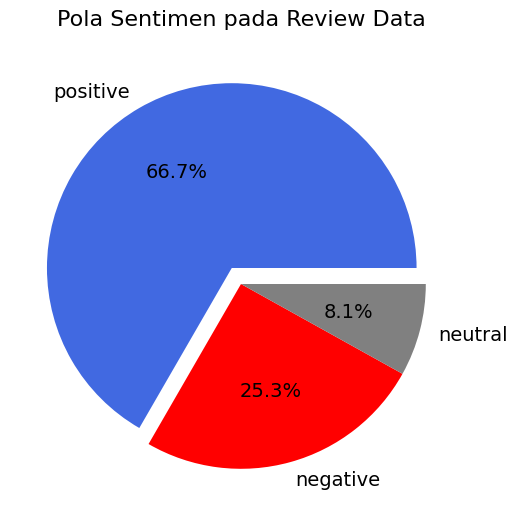

In [ ]:
# Membuat visualisasi untuk polaritas sentimen
fig, ax = plt.subplots(figsize=(6, 6))

# Mengambil jumlah data polaritas sentimen ke dalam list sizes dan labels
sizes = clean_inshot_df['polarity'].value_counts().values
labels = clean_inshot_df['polarity'].value_counts().index.tolist()

# Memberikan warna per sentimen
color_map = {
    'positive': 'royalblue',
    'negative': 'red',
    'neutral': 'gray'
}
colors = [color_map[label] for label in labels]

# Membuat efek explode, hanya memisahkan bagian pertama dari pie chart.
explode = [0.1] + [0 for _ in range(len(sizes) - 1)]

# Membuat pie chart
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14}, colors=colors)

# Menetapkan judul
ax.set_title('Pola Sentimen pada Review Data', fontsize=16, pad=20)

# Menampilkan pie chart
plt.show()


In [ ]:
pd.set_option('display.max_colwidth', 5000) # Menampilkan seluruh isi kolom hingga 5000 karakter

# Fungsi untuk membuat DataFrame berdasarkan polaritas
def create_sentiment_df(df, sentiment):
  sentiment_df = df.loc[df['polarity'] == sentiment, ['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
  sentiment_df = sentiment_df.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)
  sentiment_df.index += 1
  return sentiment_df

positive_reviews = create_sentiment_df(clean_inshot_df, 'positive')
negative_reviews = create_sentiment_df(clean_inshot_df, 'negative')
neutral_reviews = create_sentiment_df(clean_inshot_df, 'neutral')

In [ ]:
# Fungsi untuk membuat dan menampilkan WordCloud
def plot_wordcloud(data, title):
  all_words = ''
  for sentence in data:
    for word in sentence:
      all_words += ' ' + word
  wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(all_words)
  plt.figure(figsize=(8, 6))
  plt.title(title, fontsize=18)
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.tight_layout(pad=0)
  plt.show()

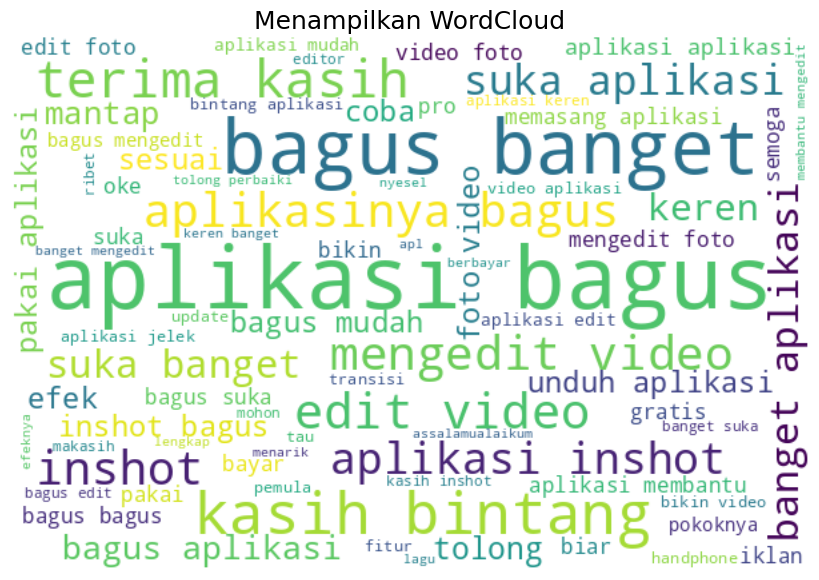

In [ ]:
# WordCloud untuk semua review
plot_wordcloud(clean_inshot_df['text_stopword'], 'Menampilkan WordCloud')


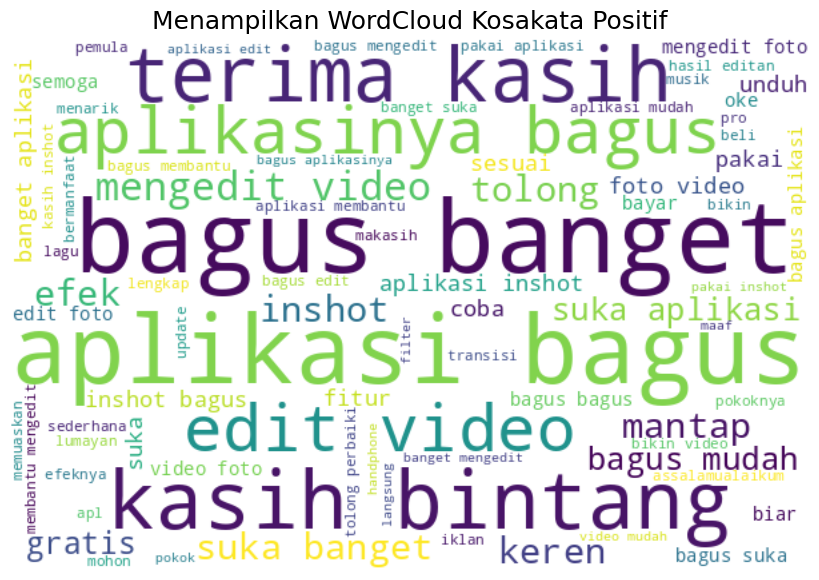

In [ ]:
# WordCloud untuk review positif
plot_wordcloud(positive_reviews['text_stopword'], 'Menampilkan WordCloud Kosakata Positif')

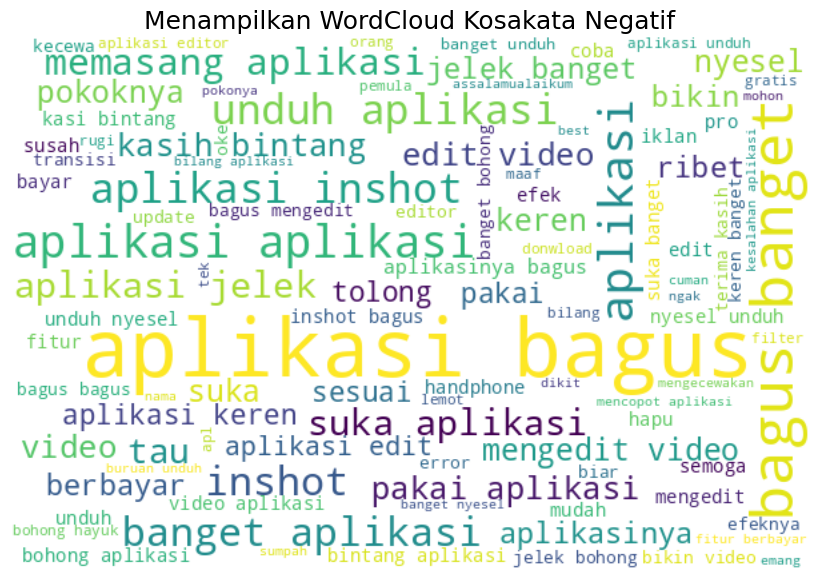

In [ ]:
# WordCloud untuk review negatif
plot_wordcloud(negative_reviews['text_stopword'], 'Menampilkan WordCloud Kosakata Negatif')

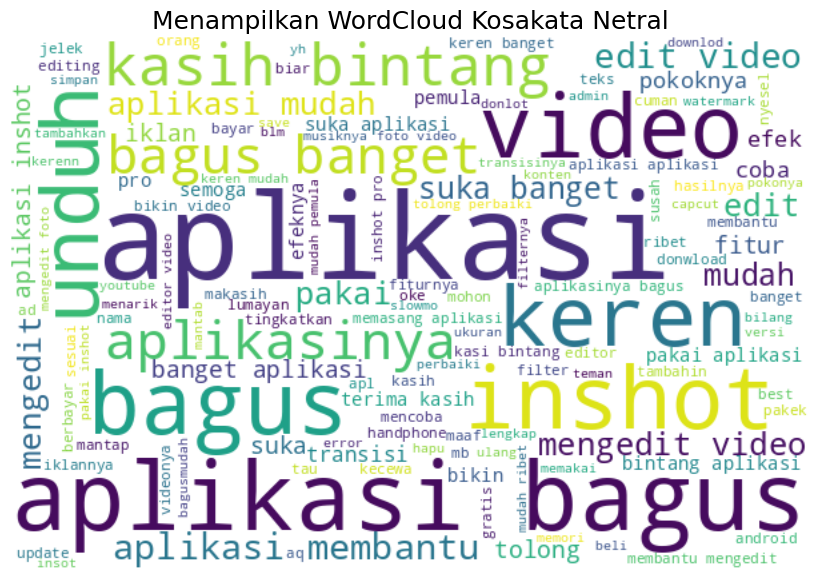

In [ ]:
# WordCloud untuk review netral
plot_wordcloud(neutral_reviews['text_stopword'], 'Menampilkan WordCloud Kosakata Netral')

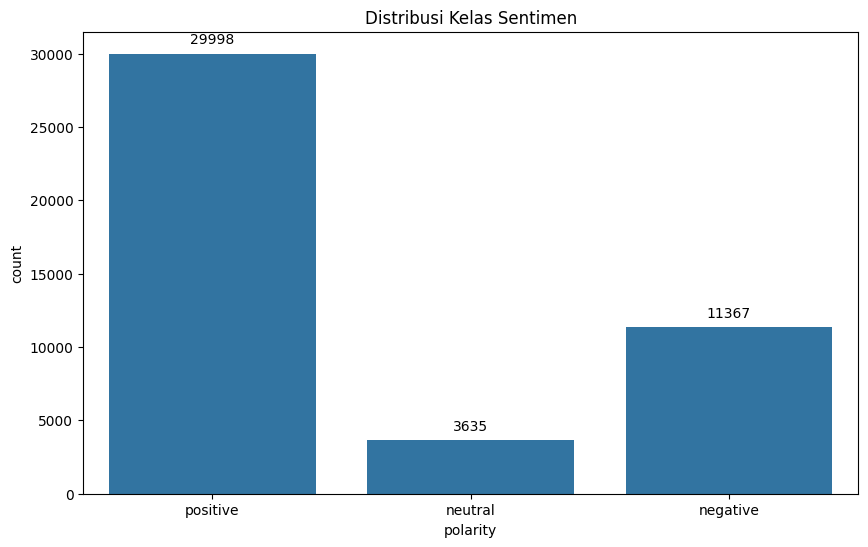

In [ ]:
# Visualisasi distribusi kelas sentimen
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='polarity', data=clean_inshot_df)
plt.title('Distribusi Kelas Sentimen')

# Menampilkan jumlah di atas bar
for p in ax.patches:ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center',
                                xytext=(0, 10), textcoords='offset points')
plt.show()


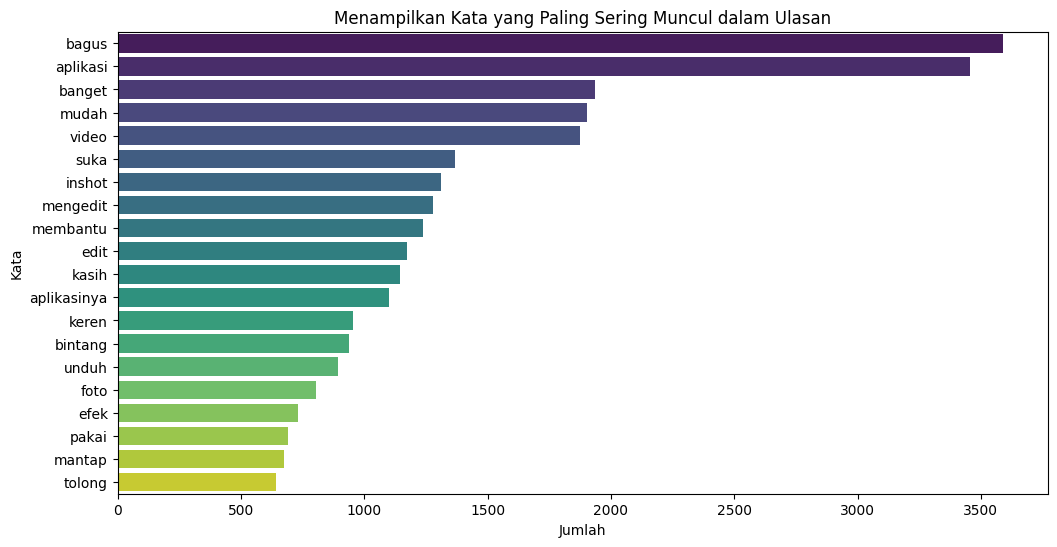

In [ ]:
# Visualisasi 20 kata paling sering muncul
plt.figure(figsize=(12, 6))
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_inshot_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Menghitung total skor tiap kata
word_freq = tfidf_df.sum().reset_index(name='jumlah')
word_freq.columns = ['kata', 'jumlah']
top_words = word_freq.sort_values('jumlah', ascending=False).head(20)

sns.barplot(x='jumlah', y='kata', data=top_words, palette='viridis', hue='kata')
plt.title('Menampilkan Kata yang Paling Sering Muncul dalam Ulasan')
plt.xlabel('Jumlah')
plt.ylabel('Kata')
plt.show()

In [ ]:
# Menyimpan ke CSV

clean_inshot_df.to_csv('ulasan_inshot.csv', index=False, encoding='utf-8')

- Hasil dari pie chart menunjukkan bahwa kosakata positif terdapat 66.7%, negatif 25.3% dan netral 8.1%.

- Sentimen positif lebih banyak dalam ulasan aplikasi Inshot, yang berarti user merasa puas dan terbantu oleh aplikasi tersebut.

- Untuk sentimen negatifnya terdapat beberapa seperti kata iklan, berbayar, pro, yang artinya user merasa kurang puas dengan fitur yang disediakan Inshot apabila gratis, dan beberapa fitur yang sangat dibutuhkan justru harus berbayar terlebih dahulu.

- Setelah membuat visualisasi kata yang sering muncul dalam ulasan yaitu kata bagus, yang berarti sebagian besar user merasa puas dengan aplikasi Inshot.